# MASTER US — 训练 & 分析（Daily Alpha158）

一站式 Notebook：**Walk-forward 训练** + **IC / RankIC / Portfolio PnL**

**数据**：`data/spx_stock_data.csv`（WRDS CRSP 日频）→ Alpha158（158）+ 市场 gate（63）+ 5日 forward label

**设置**：20 年训练 / 每 10 年 refit（2000、2010、2020）/ lookback T=8 **交易日**

**流程**：
1. 数据准备（`RUN_DATA_PREP=True`：下载指数 + 构建 panel）
2. Walk-forward 训练
3. IC、Rank IC、Long-Short PnL、Sharpe、CAPM

> Kernel 选已安装 `torch` 的 Conda 环境；有 GPU 时设 `GPU_ID = 0`

In [1]:
# ============ 训练参数 ============
REFIT_YEARS = [2000, 2010, 2020]
SEED = 0
GPU_ID = 0                         # GPU 编号；-1 强制 CPU
SMOKE_TEST = False                 # True: 每折只跑 2 epoch
RUN_DATA_PREP = False              # True: 重新下载市场数据并建面板
SKIP_TRAINING = False              # True: 跳过训练，直接用已保存的预测做分析
RETRAIN = False                     # True: 清空旧结果并重新训练
N_EPOCH_OVERRIDE = None            # None 用 config 默认 40
EARLY_STOP_PATIENCE = 10           # 验证集指标连续 N 个 epoch 不提升则停止
EARLY_STOP_METRIC = "IC"           # 早停监控指标: "IC" 或 "RIC"

# ============ 组合分析参数 ============
TOP_PCT = 0.10                     # long top 10%
BOTTOM_PCT = 0.10                  # short bottom 10%
MIN_STOCKS = 20                    # 每月最少股票数

In [2]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

ROOT = Path(".").resolve()
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from config import (
    BETA, D_FEAT, D_MODEL, DROPOUT, EARLY_STOP_METRIC, EARLY_STOP_PATIENCE,
    GATE_INPUT_END, GATE_INPUT_START,
    LABEL_COL, LABEL_FORWARD_DAYS, LR, MARKET_FEATURES_CSV, MASTER_PANEL_PARQUET,
    N_EPOCH, OUTPUT_DIR, TRAIN_STOP_LOSS_THRED, T_NHEAD, S_NHEAD,
)
from scripts.run_walkforward import run_fold
from scripts.eval_utils import build_eval_frame, calc_ic_series, verify_saved_ic

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "models").mkdir(parents=True, exist_ok=True)

PRED_PATH = OUTPUT_DIR / "predictions.parquet"
METRICS_PATH = OUTPUT_DIR / "metrics_summary.csv"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (12, 5), "font.size": 11})

print(f"Project root: {ROOT}")
print(f"Panel path:   {MASTER_PANEL_PARQUET}")

Project root: C:\Users\Lenovo\Desktop\MASTER_SPX
Panel path:   C:\Users\Lenovo\Desktop\MASTER_SPX\data\processed\master_panel_long.parquet


## 1. 数据准备

In [3]:
if RUN_DATA_PREP:
    import subprocess
    for script in [
        "scripts/download_market_data.py",
        "scripts/build_market_features.py",
        "scripts/build_master_panel.py",
    ]:
        print("Running", script)
        subprocess.check_call([sys.executable, str(ROOT / script)])
else:
    if MASTER_PANEL_PARQUET.exists():
        print(f"Panel exists: {MASTER_PANEL_PARQUET}")
    else:
        raise FileNotFoundError(
            f"Missing {MASTER_PANEL_PARQUET}. Set RUN_DATA_PREP=True or run data scripts first."
        )

Panel exists: C:\Users\Lenovo\Desktop\MASTER_SPX\data\processed\master_panel_long.parquet


## 2. GPU / 环境检查

In [4]:
if GPU_ID >= 0 and torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(GPU_ID)} (cuda:{GPU_ID})")
    gpu = GPU_ID
elif GPU_ID >= 0:
    print("WARNING: CUDA not available, falling back to CPU.")
    print("Install CUDA PyTorch: pip install torch --index-url https://download.pytorch.org/whl/cu124")
    gpu = 0
else:
    print("Using CPU (GPU_ID=-1)")
    gpu = 0

n_epoch = 2 if SMOKE_TEST else (N_EPOCH_OVERRIDE or N_EPOCH)
print(f"Folds: {REFIT_YEARS} | max epochs per fold: {n_epoch}")
print(f"Early stop: monitor {EARLY_STOP_METRIC}, patience={EARLY_STOP_PATIENCE}")

Using GPU: NVIDIA GeForce GTX 1650 (cuda:0)
Folds: [2000, 2010, 2020] | max epochs per fold: 40
Early stop: monitor IC, patience=10


## 3. 加载数据 & 定义训练函数

In [5]:
import pyarrow.parquet as pq

meta = pq.read_metadata(MASTER_PANEL_PARQUET)
print(f"Panel parquet: {MASTER_PANEL_PARQUET}")
print(f"Rows: {meta.num_rows:,} | Cols: {meta.num_columns}")
print("Training reads per-fold slices only (no full panel load).")
print("Tip: run one fold at a time, e.g. REFIT_YEARS = [2000]")

Panel parquet: C:\Users\Lenovo\Desktop\MASTER_SPX\data\processed\master_panel_long.parquet
Rows: 4,510,308 | Cols: 225
Training reads per-fold slices only (no full panel load).
Tip: run one fold at a time, e.g. REFIT_YEARS = [2000]


## 4. Walk-Forward 训练

第一折数据准备约 **1–2 分钟**，之后会出现 epoch 进度条。完整 3 折训练可能需要 **数小时**（视 GPU/CPU 而定）。

**参数说明**：
- `SKIP_TRAINING=True`：跳过训练，直接加载已保存结果做分析
- `RETRAIN=True`：清空旧结果并从头训练（预测与 label 一并保存）
- 训练结束后会自动校验 saved IC vs 分析 IC 是否一致

In [6]:
import shutil


def clean_outputs():
    """Remove stale predictions/metrics/models before a fresh run."""
    for path in (PRED_PATH, METRICS_PATH):
        if path.exists():
            path.unlink()
            print(f"Removed {path}")
    models_dir = OUTPUT_DIR / "models"
    if models_dir.exists():
        shutil.rmtree(models_dir)
        print(f"Removed {models_dir}")
    models_dir.mkdir(parents=True, exist_ok=True)


def load_saved_results():
    if not PRED_PATH.exists():
        raise FileNotFoundError(f"Not found: {PRED_PATH}. Set SKIP_TRAINING=False to train first.")
    if not METRICS_PATH.exists():
        raise FileNotFoundError(f"Not found: {METRICS_PATH}. Set SKIP_TRAINING=False to train first.")
    pred_df = pd.read_parquet(PRED_PATH)
    metrics_df = pd.read_csv(METRICS_PATH)
    if LABEL_COL not in pred_df.columns:
        raise ValueError(
            f"Saved predictions missing {LABEL_COL}. Run with RETRAIN=True to regenerate."
        )
    return pred_df, metrics_df


def save_results(pred_df, metrics_df):
    pred_df.to_parquet(PRED_PATH)
    metrics_df.to_csv(METRICS_PATH, index=False)
    print(f"Saved predictions -> {PRED_PATH}")
    print(f"Saved metrics     -> {METRICS_PATH}")
    print(f"Saved models      -> {OUTPUT_DIR / 'models'}")


if SKIP_TRAINING:
    print("SKIP_TRAINING=True: loading saved results...")
    pred_df, metrics_df = load_saved_results()
    display(metrics_df)
    display(verify_saved_ic(pred_df, metrics_df))
else:
    if RETRAIN:
        print("RETRAIN=True: cleaning old outputs and training from scratch...")
        clean_outputs()
    else:
        print("RETRAIN=False: continuing training (will overwrite outputs each fold)...")

    all_preds = []
    metrics_rows = []

    print("First fold data prep takes ~1-2 min before epoch bar appears...")
    for year in tqdm(REFIT_YEARS, desc="walk-forward folds"):
        preds, metrics = run_fold(
            MASTER_PANEL_PARQUET,
            year,
            seed=SEED,
            n_epoch=n_epoch,
            gpu=gpu,
            smoke=SMOKE_TEST,
        )
        all_preds.append(preds)
        metrics_rows.append({"refit_year": year, **metrics})

        pred_df = pd.concat(all_preds)
        metrics_df = pd.DataFrame(metrics_rows)
        save_results(pred_df, metrics_df)
        print(f"  [fold {year} done, checkpoint saved]")

    print("\n=== Per-fold OOS ===")
    display(metrics_df)
    print("\n=== Mean OOS ===")
    display(metrics_df.mean(numeric_only=True))
    print("\n=== IC consistency check (saved vs recomputed) ===")
    display(verify_saved_ic(pred_df, metrics_df))

RETRAIN=False: continuing training (will overwrite outputs each fold)...
First fold data prep takes ~1-2 min before epoch bar appears...


walk-forward folds:   0%|          | 0/3 [00:00<?, ?it/s]


[fold 2000] Computing fold dates (datetime only) ...
[fold 2000] Loading train/val slice: 1989-11-03 -> 1999-12-31 ...


prepare from fold:   0%|          | 0/1 [00:00<?, ?it/s]

cache instruments:   0%|          | 0/721 [00:00<?, ?it/s]

...

,refit_year,IC,ICIR,RIC,RICIR
0,2000,0.049710,0.418239,0.055604,0.483905
1,2010,0.012627,0.095384,0.018868,0.148707
2,2020,0.016443,0.105899,0.019733,0.125062



=== Mean OOS ===


refit_year    2010.000000
IC               0.026260
ICIR             0.206507
RIC              0.031402
RICIR            0.252558
dtype: float64


=== IC consistency check (saved vs recomputed) ===


,refit_year,saved_IC,recomputed_IC,gap
0,2000,0.049710,0.046342,-0.003368
1,2010,0.012627,0.002882,-0.009745
2,2020,0.016443,0.030839,0.014395


## 5. 分析函数

In [17]:
def long_short_pnl(
    df,
    top_pct=TOP_PCT,
    bottom_pct=BOTTOM_PCT,
    min_stocks=MIN_STOCKS,
    rebalance_days=LABEL_FORWARD_DAYS,
    label_clip=1.0,
) -> pd.DataFrame:
    """Long-short PnL with Portfolio Turnover calculation: rebalance every `rebalance_days` trading days (non-overlapping).

    Label is the 5-day forward return (close[t+5]/close[t]-1); each rebalance
    date holds one non-overlapping 5-day position.
    """
    all_dates = sorted(df.index.get_level_values("datetime").unique())
    rebalance_dates = all_dates[::rebalance_days]

    rows = []
    prev_longs = None
    prev_shorts = None
    for dt in rebalance_dates:
        try:
            g = df.xs(dt, level="datetime")
        except KeyError:
            continue
        n = len(g)
        if n < min_stocks:
            continue
        k_top = max(1, int(np.floor(n * top_pct)))
        k_bot = max(1, int(np.floor(n * bottom_pct)))
        g = g.sort_values("pred", ascending=False)
        
        # Identify current selected instruments in each leg
        longs = set(g.head(k_top).index)
        shorts = set(g.tail(k_bot).index)
        
        # Calculate Turnover (one-sided) as 1.0 - overlap_ratio for each leg
        if prev_longs is not None and prev_shorts is not None:
            long_to = 1.0 - (len(longs.intersection(prev_longs)) / k_top)
            short_to = 1.0 - (len(shorts.intersection(prev_shorts)) / k_bot)
            port_to = (long_to + short_to) / 2.0
        else:
            port_to = np.nan
            
        ret = g[LABEL_COL].clip(-label_clip, label_clip)
        long_ret = ret.head(k_top).mean()
        bottom_ret = ret.tail(k_bot).mean()
        short_ret = -bottom_ret
        rows.append({
            "datetime": dt,
            "long": long_ret,
            "bottom_ret": bottom_ret,
            "short": short_ret,
            "ls": long_ret + short_ret,
            "n": n,
            "k_top": k_top,
            "k_bot": k_bot,
            "portfolio_turnover": port_to,
        })
        prev_longs = longs
        prev_shorts = shorts

    pnl = pd.DataFrame(rows).set_index("datetime").sort_index()
    pnl["cum_ls"] = (1 + pnl["ls"]).cumprod() - 1
    pnl["cum_long"] = (1 + pnl["long"]).cumprod() - 1
    pnl["cum_short"] = (1 + pnl["short"]).cumprod() - 1
    return pnl


def portfolio_stats(
    period_rets: pd.Series,
    periods_per_year: int | None = None,
    hold_days: int = LABEL_FORWARD_DAYS,
) -> pd.Series:
    """Annual return and Sharpe from per-period (e.g. 5-day) returns."""
    if periods_per_year is None:
        periods_per_year = max(1, int(252 / hold_days))
    r = period_rets.dropna()
    if len(r) == 0 or r.std() == 0:
        return pd.Series({"ann_return": np.nan, "sharpe": np.nan, "n_periods": len(r)})
    ann_return = (1 + r).prod() ** (periods_per_year / len(r)) - 1
    sharpe = r.mean() / r.std() * np.sqrt(periods_per_year)
    return pd.Series({"ann_return": ann_return, "sharpe": sharpe, "n_periods": len(r)})


def load_spx_daily_return(market_path=MARKET_FEATURES_CSV) -> pd.Series:
    """Load SPX daily return, indexed by calendar date."""
    mkt = pd.read_csv(market_path, index_col=0, parse_dates=True)
    spx = mkt["SPX_ret_1d"].copy()
    spx.index = pd.to_datetime(spx.index).normalize()
    return spx.rename("spx")


def load_spx_holding_return(
    rebalance_dates,
    forward_days: int = LABEL_FORWARD_DAYS,
    market_path=MARKET_FEATURES_CSV,
) -> pd.Series:
    """SPX return over the same holding window as label: close[t+5]/close[t]-1."""
    spx = load_spx_daily_return(market_path)
    cal = spx.index.sort_values()
    out = {}
    for dt in rebalance_dates:
        t = pd.Timestamp(dt).normalize()
        if t not in cal:
            continue
        idx = cal.get_loc(t)
        if idx + forward_days >= len(cal):
            continue
        # close[t+5]/close[t]-1 = prod(1+ret) for days t+1..t+5
        period_ret = (1 + spx.iloc[idx + 1 : idx + forward_days + 1]).prod() - 1
        out[t] = period_ret
    return pd.Series(out, name="spx")


def capm_alpha_beta(
    portfolio_rets: pd.Series,
    market_rets: pd.Series,
    periods_per_year: int | None = None,
    hold_days: int = LABEL_FORWARD_DAYS,
) -> pd.Series:
    """CAPM on per-period returns (aligned with 5-day holding periods)."""
    if periods_per_year is None:
        periods_per_year = max(1, int(252 / hold_days))
    port = portfolio_rets.copy()
    port.index = pd.to_datetime(port.index).normalize()
    mkt = market_rets.copy()
    mkt.index = pd.to_datetime(mkt.index).normalize()
    df = pd.concat([port.rename("port"), mkt], axis=1).dropna()
    if len(df) < 2 or df["spx"].std() == 0:
        return pd.Series({
            "corr_spx": np.nan, "beta": np.nan,
            "alpha_period": np.nan, "alpha_annual": np.nan, "n_periods": len(df),
        })
    p, m = df["port"], df["spx"]
    corr = p.corr(m)
    beta = corr * p.std() / m.std()
    alpha_period = p.mean() - beta * m.mean()
    return pd.Series({
        "corr_spx": corr, "beta": beta,
        "alpha_period": alpha_period,
        "alpha_annual": alpha_period * periods_per_year,
        "n_periods": len(df),
    })

In [8]:
eval_df = build_eval_frame(pred_df)
ic_df = calc_ic_series(eval_df)
pnl_df = long_short_pnl(eval_df)

print(f"Samples: {len(eval_df):,}")
print(f"Date range: {eval_df.index.get_level_values(0).min().date()} -> {eval_df.index.get_level_values(0).max().date()}")
print(f"Trading days: {len(ic_df)}")
print("\nIC summary:")
print(f"  Mean IC:      {ic_df['IC'].mean():.4f}")
print(f"  ICIR:         {ic_df['IC'].mean() / ic_df['IC'].std():.4f}")
print(f"  Mean RankIC:  {ic_df['RankIC'].mean():.4f}")
print(f"  RankICIR:     {ic_df['RankIC'].mean() / ic_df['RankIC'].std():.4f}")
REBALANCE_PERIODS_PER_YEAR = max(1, 252 // LABEL_FORWARD_DAYS)

print(f"Rebalance: every {LABEL_FORWARD_DAYS} trading days | periods/year ≈ {REBALANCE_PERIODS_PER_YEAR}")
print(f"Portfolio periods: {len(pnl_df)}")

print("\nLong-Short portfolio (Top/Bottom 10%):")
ls_stats = portfolio_stats(pnl_df["ls"], periods_per_year=REBALANCE_PERIODS_PER_YEAR)
long_stats = portfolio_stats(pnl_df["long"], periods_per_year=REBALANCE_PERIODS_PER_YEAR)
short_stats = portfolio_stats(pnl_df["short"], periods_per_year=REBALANCE_PERIODS_PER_YEAR)
print(f"  Mean 5-day return: {pnl_df['ls'].mean():.4f}")
print(f"  Total cum return:  {pnl_df['cum_ls'].iloc[-1]:.4f}")
print(f"  Annual return:     {ls_stats['ann_return']:.2%}")
print(f"  Sharpe ratio:      {ls_stats['sharpe']:.2f}")

print("\nLong-only:")
print(f"  Annual return: {long_stats['ann_return']:.2%} | Sharpe: {long_stats['sharpe']:.2f}")
print("Short-only:")
print(f"  Annual return: {short_stats['ann_return']:.2%} | Sharpe: {short_stats['sharpe']:.2f}")

stats_df = pd.DataFrame({
    "Long-Short": portfolio_stats(pnl_df["ls"], periods_per_year=REBALANCE_PERIODS_PER_YEAR),
    "Long-only": portfolio_stats(pnl_df["long"], periods_per_year=REBALANCE_PERIODS_PER_YEAR),
    "Short-only": portfolio_stats(pnl_df["short"], periods_per_year=REBALANCE_PERIODS_PER_YEAR),
}).T[["ann_return", "sharpe", "n_periods"]]
print("\nPortfolio stats summary:")
display(stats_df.style.format({"ann_return": "{:.2%}", "sharpe": "{:.2f}", "n_periods": "{:.0f}"}))

spx_rets = load_spx_holding_return(pnl_df.index)
capm_df = pd.DataFrame({
    "Long-Short": capm_alpha_beta(pnl_df["ls"], spx_rets, periods_per_year=REBALANCE_PERIODS_PER_YEAR),
    "Long-only": capm_alpha_beta(pnl_df["long"], spx_rets, periods_per_year=REBALANCE_PERIODS_PER_YEAR),
    "Short-only": capm_alpha_beta(pnl_df["short"], spx_rets, periods_per_year=REBALANCE_PERIODS_PER_YEAR),
}).T[["corr_spx", "beta", "alpha_period", "alpha_annual", "n_periods"]]
print("\nCAPM vs SPX (5-day holding return vs SPX 5-day return):")
print("  beta = corr(port, SPX) * std(port) / std(SPX)")
print("  alpha_period = mean(port) - beta * mean(SPX)")
display(capm_df.style.format({
    "corr_spx": "{:.3f}",
    "beta": "{:.3f}",
    "alpha_period": "{:.4f}",
    "alpha_annual": "{:.2%}",
    "n_periods": "{:.0f}",
}))

ic_df.head()

Samples: 3,245,849
Date range: 2000-01-03 -> 2025-12-23
Trading days: 6534

IC summary:
  Mean IC:      0.0260
  ICIR:         0.4195
  Mean RankIC:  0.0244
  RankICIR:     0.4980
Rebalance: every 5 trading days | periods/year ≈ 50
Portfolio periods: 1307

Long-Short portfolio (Top/Bottom 10%):
  Mean 5-day return: 0.0056
  Total cum return:  1363.3151
  Annual return:     31.80%
  Sharpe ratio:      2.85

Long-only:
  Annual return: 31.21% | Sharpe: 3.95
Short-only:
  Annual return: 0.50% | Sharpe: 0.11

Portfolio stats summary:


,ann_return,sharpe,n_periods
Long-Short,31.80%,2.85,1307
Long-only,31.21%,3.95,1307
Short-only,0.50%,0.11,1307



CAPM vs SPX (5-day holding return vs SPX 5-day return):
  beta = corr(port, SPX) * std(port) / std(SPX)
  alpha_period = mean(port) - beta * mean(SPX)


,corr_spx,beta,alpha_period,alpha_annual,n_periods
Long-Short,-0.049,-0.027,0.0057,28.38%,1307
Long-only,-0.023,-0.009,0.0055,27.54%,1307
Short-only,-0.051,-0.018,0.0002,0.84%,1307


,IC,RankIC,n,cum_IC,cum_RankIC
datetime,,,,,
2000-01-03,0.109537,0.082663,496.0,0.109537,0.082663
2000-01-04,0.022063,0.014040,496.0,0.131600,0.096703
2000-01-05,0.130960,0.075572,496.0,0.262560,0.172275
2000-01-06,0.073626,0.033277,496.0,0.336186,0.205553
2000-01-07,-0.003662,-0.023629,496.0,0.332524,0.181924


## 6. IC & Cumulative IC

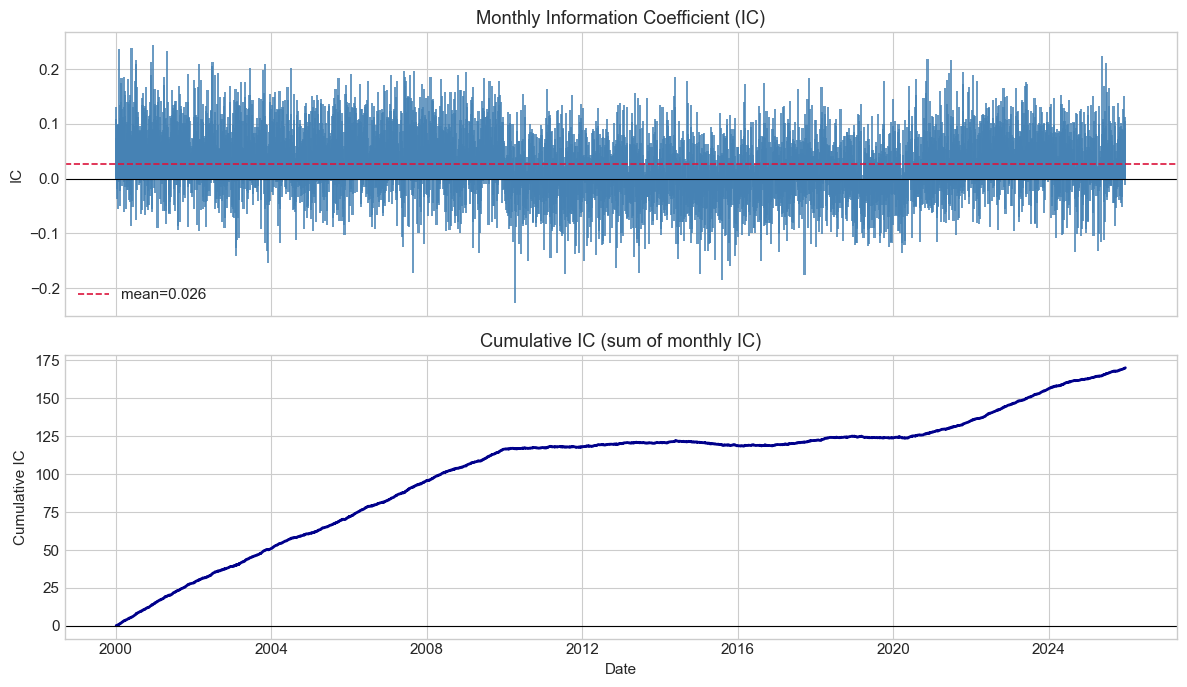

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].bar(ic_df.index, ic_df["IC"], width=20, color="steelblue", alpha=0.8)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].axhline(ic_df["IC"].mean(), color="crimson", ls="--", lw=1.2, label=f"mean={ic_df['IC'].mean():.3f}")
axes[0].set_ylabel("IC")
axes[0].set_title("Monthly Information Coefficient (IC)")
axes[0].legend()

axes[1].plot(ic_df.index, ic_df["cum_IC"], color="darkblue", lw=2)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("Cumulative IC")
axes[1].set_title("Cumulative IC (sum of monthly IC)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

## 7. Rank IC & Cumulative Rank IC

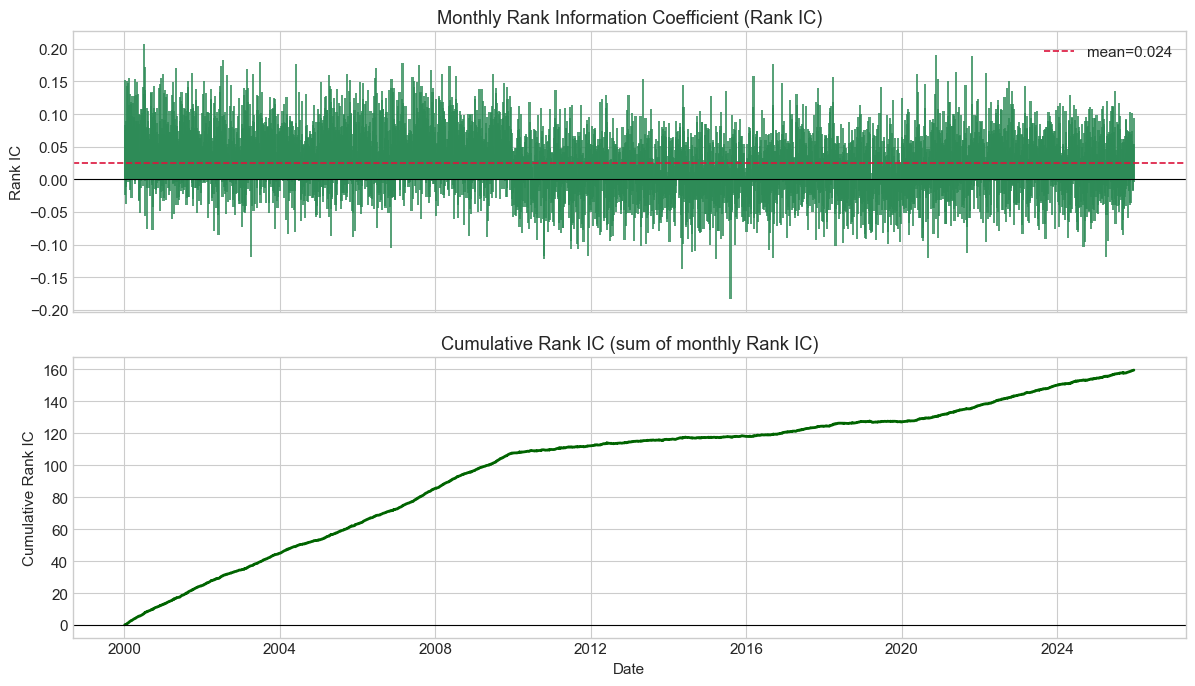

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].bar(ic_df.index, ic_df["RankIC"], width=20, color="seagreen", alpha=0.8)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].axhline(ic_df["RankIC"].mean(), color="crimson", ls="--", lw=1.2, label=f"mean={ic_df['RankIC'].mean():.3f}")
axes[0].set_ylabel("Rank IC")
axes[0].set_title("Monthly Rank Information Coefficient (Rank IC)")
axes[0].legend()

axes[1].plot(ic_df.index, ic_df["cum_RankIC"], color="darkgreen", lw=2)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("Cumulative Rank IC")
axes[1].set_title("Cumulative Rank IC (sum of monthly Rank IC)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

## 8. Portfolio PnL (Long Top 10% / Short Bottom 10%)

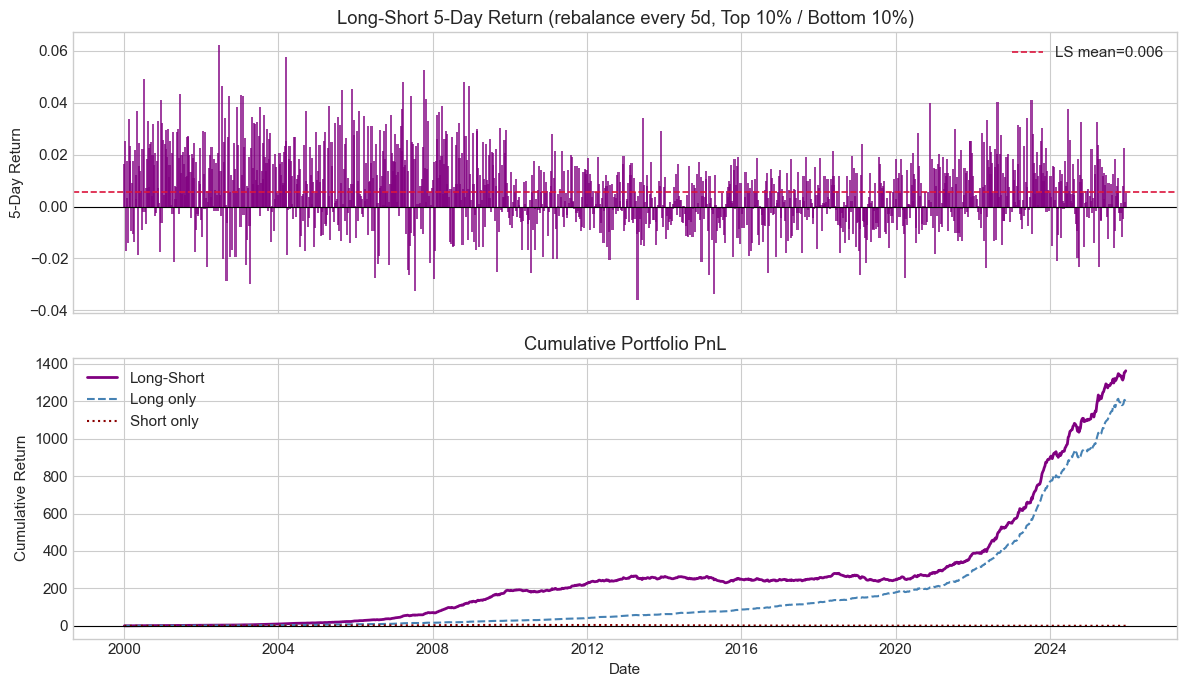

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].bar(pnl_df.index, pnl_df["ls"], width=20, color="purple", alpha=0.75)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].axhline(pnl_df["ls"].mean(), color="crimson", ls="--", lw=1.2, label=f"LS mean={pnl_df['ls'].mean():.3f}")
axes[0].set_ylabel("5-Day Return")
axes[0].set_title(f"Long-Short 5-Day Return (rebalance every {LABEL_FORWARD_DAYS}d, Top {TOP_PCT:.0%} / Bottom {BOTTOM_PCT:.0%})")
axes[0].legend()

axes[1].plot(pnl_df.index, pnl_df["cum_ls"], label="Long-Short", color="purple", lw=2)
axes[1].plot(pnl_df.index, pnl_df["cum_long"], label="Long only", color="steelblue", lw=1.5, ls="--")
axes[1].plot(pnl_df.index, pnl_df["cum_short"], label="Short only", color="darkred", lw=1.5, ls=":")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("Cumulative Return")
axes[1].set_title("Cumulative Portfolio PnL")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. 总览（4-in-1）

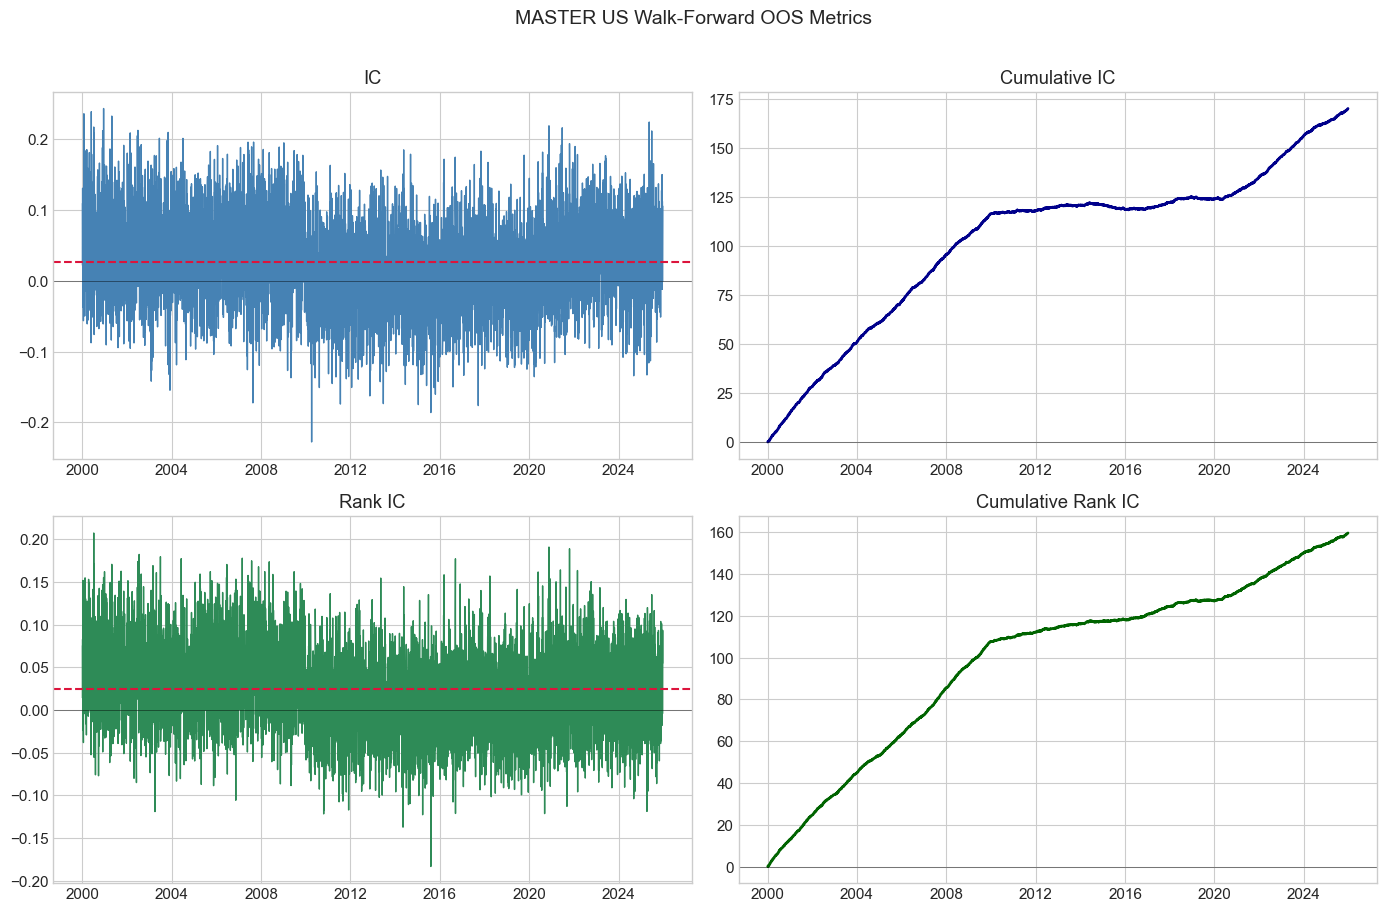

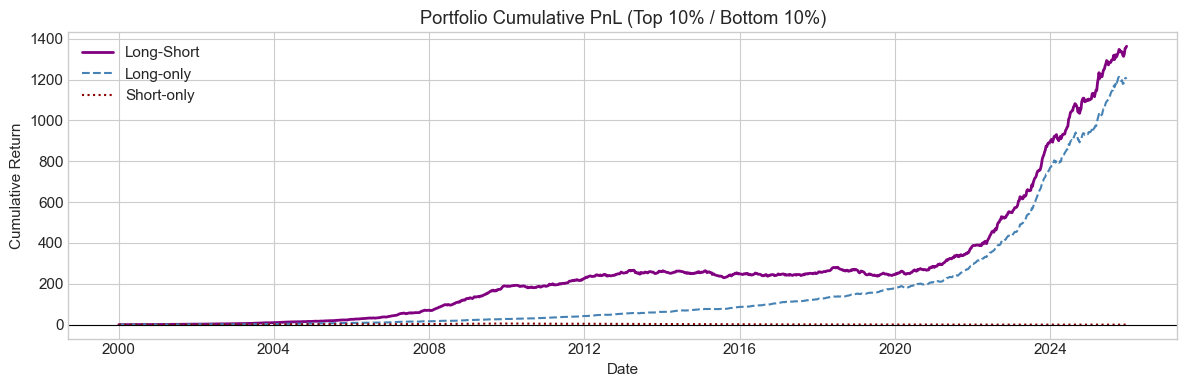

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(ic_df.index, ic_df["IC"], color="steelblue", lw=1)
axes[0, 0].axhline(ic_df["IC"].mean(), color="crimson", ls="--")
axes[0, 0].set_title("IC")

axes[0, 1].plot(ic_df.index, ic_df["cum_IC"], color="darkblue", lw=2)
axes[0, 1].set_title("Cumulative IC")

axes[1, 0].plot(ic_df.index, ic_df["RankIC"], color="seagreen", lw=1)
axes[1, 0].axhline(ic_df["RankIC"].mean(), color="crimson", ls="--")
axes[1, 0].set_title("Rank IC")

axes[1, 1].plot(ic_df.index, ic_df["cum_RankIC"], color="darkgreen", lw=2)
axes[1, 1].set_title("Cumulative Rank IC")

for ax in axes.flat:
    ax.axhline(0, color="black", lw=0.6, alpha=0.5)

plt.suptitle("MASTER US Walk-Forward OOS Metrics", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(pnl_df.index, pnl_df["cum_ls"], color="purple", lw=2, label="Long-Short")
ax.plot(pnl_df.index, pnl_df["cum_long"], color="steelblue", lw=1.5, ls="--", label="Long-only")
ax.plot(pnl_df.index, pnl_df["cum_short"], color="darkred", lw=1.5, ls=":", label="Short-only")
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Portfolio Cumulative PnL (Top {TOP_PCT:.0%} / Bottom {BOTTOM_PCT:.0%})")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.legend()
plt.tight_layout()
plt.show()

## 10. 新增分析图：多空组合 vs SPX 回报回归散点图 & 全市场平均换手率时序图

在这里，我们引入两个新的分析图：
1. **多空组合 (Long-Short) 5日回报 vs 标普500 (SPX) 5日回报的 CAPM 回归散点图**：通过最小二乘法进行线性拟合，斜率代表 **Beta 值**，截距代表每一期的 **Alpha (超额收益/超额表现)**。
2. **全市场股票的历史日平均换手率/月平均换手率折线图**：多空因子由于高频换手导致交易摩擦，观察市场整体日均/月均换手率的大小和时序变化，能辅助我们对换手摩擦成本和流动性进行估算。

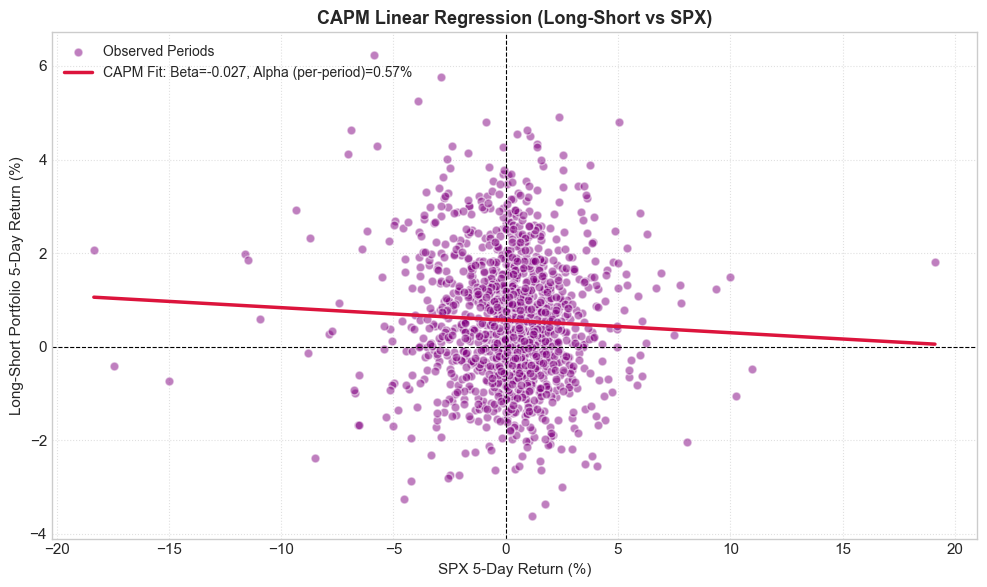

In [16]:
# 1. 组合回报 vs SPX回报 CAPM 回归散点图
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress

# 对齐日期并融合多空组合回报和 SPX 大盘持仓回报
aligned_df = pd.concat([pnl_df["ls"].rename("port_ls"), spx_rets.rename("spx")], axis=1).dropna()

# 计算 Beta 和 Alpha 截距
slope, intercept, r_value, p_value, std_err = linregress(aligned_df["spx"], aligned_df["port_ls"])

plt.figure(figsize=(10, 6))

# 绘制散点图和 OLS 拟合线
plt.scatter(aligned_df["spx"] * 100, aligned_df["port_ls"] * 100, color="purple", alpha=0.5, edgecolors="white", s=40, label="Observed Periods")
x_range = np.linspace(aligned_df["spx"].min(), aligned_df["spx"].max(), 100)
plt.plot(x_range * 100, (slope * x_range + intercept) * 100, color="crimson", lw=2.5, 
         label=f"CAPM Fit: Beta={slope:.3f}, Alpha (per-period)={intercept:.2%}")
plt.axhline(0, color="black", ls="--", lw=0.8)
plt.axvline(0, color="black", ls="--", lw=0.8)
plt.xlabel("SPX 5-Day Return (%)", fontsize=11)
plt.ylabel("Long-Short Portfolio 5-Day Return (%)", fontsize=11)
plt.title("CAPM Linear Regression (Long-Short vs SPX)", fontsize=13, fontweight="bold")
plt.legend(fontsize=10, loc="upper left")
plt.grid(True, ls=":", alpha=0.6)
plt.tight_layout()
plt.show()

## 11. 多空组合建仓/调仓时换手率（Portfolio Turnover Rate）时序走势图

展示多空组合（Long-Short Portfolio）在历史每个调仓建仓自日期 $t$ 的组合换手率。
计算公式如下：
* **单腿（单侧）换手率**：每个调仓时点，新持股标的与上一期持股标的的非重叠度：
  $$TO_{long, t} = 1 - \frac{|Long_t \cap Long_{t-1}|}{k_{top}}$$
  $$TO_{short, t} = 1 - \frac{|Short_t \cap Short_{t-1}|}{k_{bot}}$$
* **多空整体换手率**：两腿换手率的均值：
  $$TO_t = \frac{TO_{long, t} + TO_{short, t}}{2}$$

高频持仓更替伴随的建仓成本摩擦是判断多空组合生命力的核心。通过滚动平滑线可以识别其调仓稳定度。

Loading turnover rate series from Parquet...


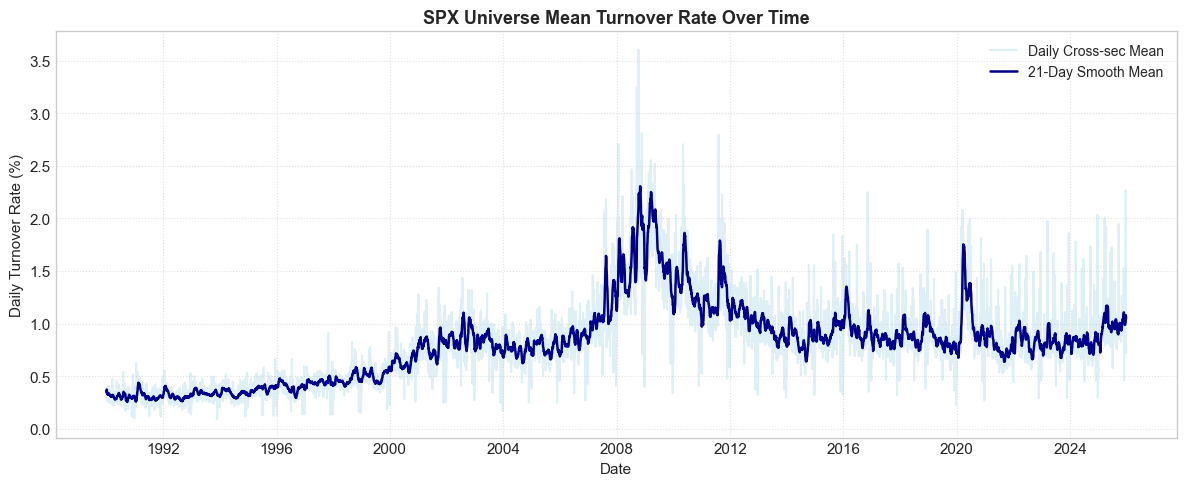

In [ ]:
# 2. 绘制多空建仓/调仓时点的组合整体换手率 (Portfolio Turnover Rate)
import matplotlib.pyplot as plt
import pandas as pd

print("Plotting portfolio rebalance turnover rate...")
if "portfolio_turnover" in pnl_df.columns:
    # 提取换手率时序
    to_series = pnl_df["portfolio_turnover"].dropna()
    # 计算平滑移动均值 (如 12期，代表约2到3个月的移动均值)
    roll_to = to_series.rolling(12, min_periods=1).mean()

    plt.figure(figsize=(12, 5))
    # 绘制实际调仓时刻组合换手率与移动平均
    plt.plot(to_series.index, to_series * 100, color="thistle", marker="o", markersize=3, alpha=0.6, label="Per-Rebalance Turnover")
    plt.plot(roll_to.index, roll_to * 100, color="purple", lw=2, label="12-Period Smooth Mean")
    
    plt.ylabel("Portfolio Turnover Rate (%)", fontsize=11)
    plt.xlabel("Rebalance Date", fontsize=11)
    plt.title(f"Long-Short Portfolio Rebalance Turnover Rate (Every {LABEL_FORWARD_DAYS} Days)", fontsize=13, fontweight="bold")
    
    # 在图表中写明平均换手率
    mean_to = to_series.mean()
    plt.axhline(mean_to * 100, color="crimson", ls="--", lw=1.2, label=f"Average Turnover={mean_to:.2%}")
    
    plt.legend(fontsize=10, loc="lower right")
    plt.grid(True, ls=":", alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("Warning: 'portfolio_turnover' not found in pnl_df. Please re-run Section 5 Cells to compute it.")